# Project Stochastic Simulation SRN

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import random as rd
import math
import scipy.stats as stats

## Section 2.1

### 2.1.1
Stochiometric vectors and propensity functions

In [14]:
nu = np.array([[-1, -1, 1, 0],[1, 1, -1, 0],[0,1,-1,1]]) # stochiometric vectors

def aCalc(x, c):
    a1 = c[0]*(x[0]*x[1])*(x[0]>=1 and x[1]>=1)
    a2 = c[1]*(x[2])*(x[2]>=1)
    a3 = c[2]*(x[2])*(x[2]>=1)
    return np.array([a1, a2, a3])

### 2.1.2

Consider the following rate constants: c1 = 0.0017, c2 = 10−4
, c3 = 0.1 and the
following initial conditions X1(0) = 312, X2(0) = 125, X3(0) = X4(0) = 0. Using the
SSA algorithm, simulate the reactions until time exceeds T = 50. Plot few realizations
of the evolution in time of each state Xi(t) and comment your results.

In [15]:
def SSA_alg(c, X0, T):

    '''
    SSA_alg takes the rate constants list c, inital condition array X0 and final time T.
    It returns an array of states X, and an array of times at wich a reaction occured.
    '''

    X = []
    X.append(X0)

    t = [0]
    n = 0
    while (t[-1]<T):
        a = aCalc(X[n], c)
        aSum = sum(a)

        u = np.random.uniform(0,1)
        P = a/aSum # Vector holding the probability of each reaction
        #F = np.array([P[0], P[0]+P[1] , P[0]+P[1]+P[2]])
        if u < P[0]:
            j = 0
        elif u < P[0]+P[1] :
            j = 1
        else :
            j = 2

        X.append(X[n]+nu[j])
        tau = np.random.exponential(1/aSum)

        t.append(t[-1] +tau)
        n += 1
    return np.array(X), np.array(t)

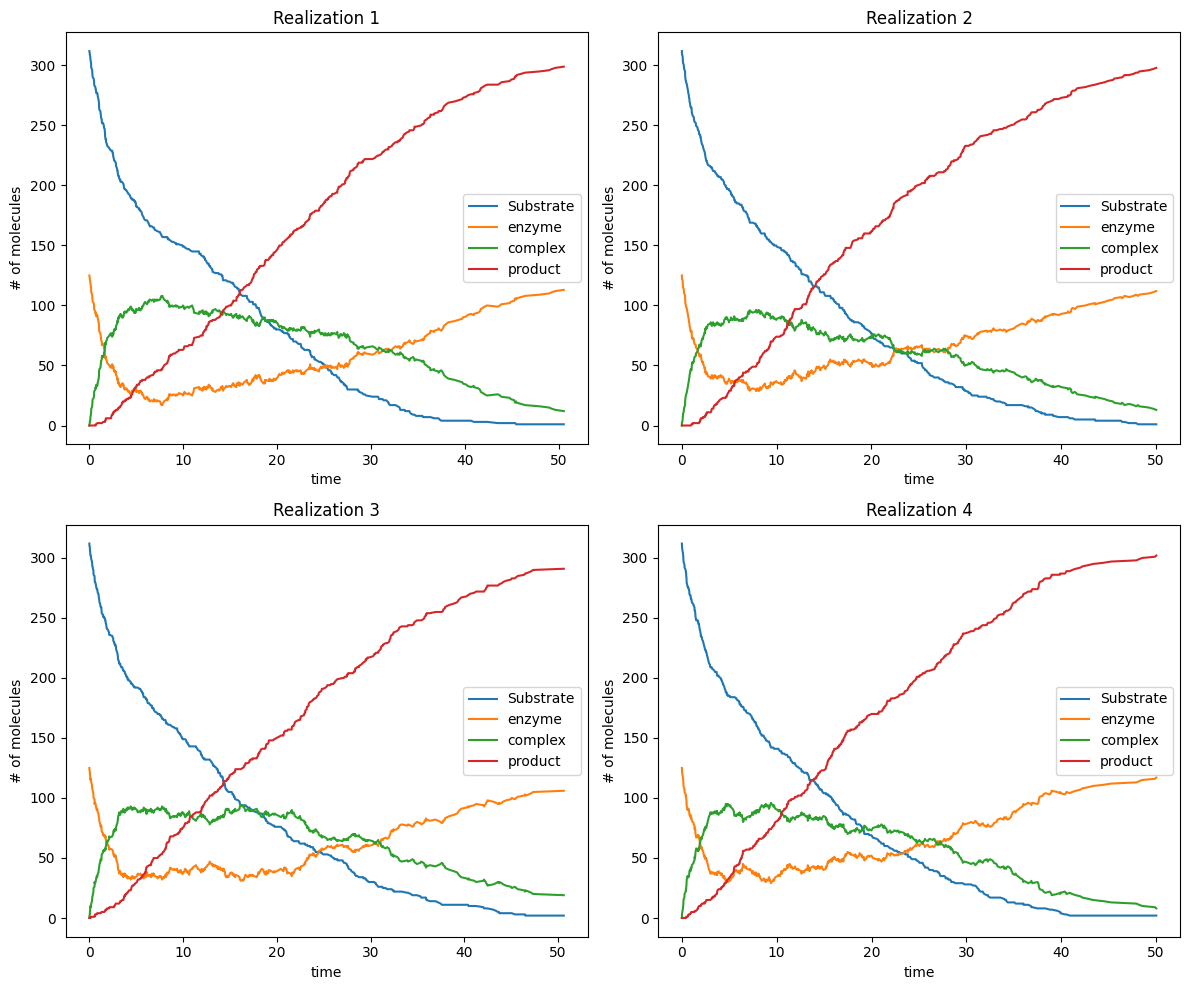

In [16]:
c = [0.0017, 1e-4, 0.1] # rate constants
T = 50 # Total time
X0 = np.array([312, 125, 0, 0])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

for i in range(4): # Loop for 4 realizations
    X, t = SSA_alg(c, X0, T)

    axes[i].plot(t, X[:,0], label="Substrate")
    axes[i].plot(t, X[:,1], label="enzyme")
    axes[i].plot(t, X[:,2], label="complex")
    axes[i].plot(t, X[:,3], label="product")

    axes[i].set_title(f"Realization {i+1}")
    axes[i].set_xlabel("time")
    axes[i].set_ylabel("# of molecules")
    axes[i].legend()

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### 2.1.3
Estimate with Monte Carlo the quantity of interest Z = E(X4(T)).
Fix a threshold for the halfwidth of a confidence interval at level 1-alpha and iteratively increase N until you achieve the desired tolerance.

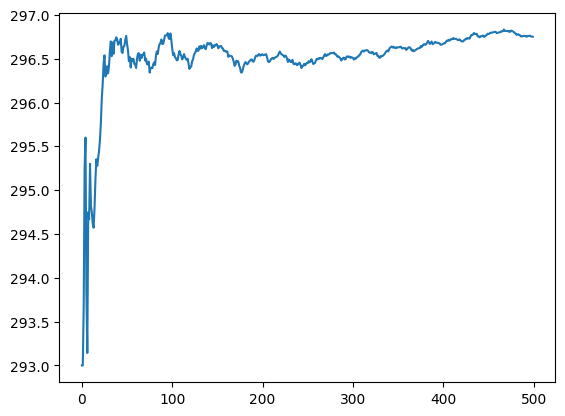

In [17]:
'''
Test plot to estimate a good Nb
'''

Nb = 500
X4 = np.zeros(Nb)
muNs= [0]

for i in range(Nb):
    X, t = SSA_alg(c, X0, T)
    X4[i] = X[-1,3]
    muNs.append((i/(i+1))*muNs[-1] + 1/(i+1) * X[-1,3])

plt.plot(range(0, Nb), muNs[1:])

In [18]:
Nb = 150
X4 = np.zeros(Nb)
muNs= [0]
for i in range(Nb):
    X, t = SSA_alg(c, X0, T)
    X4[i] = X[-1,3]
    muNs.append((i/(i+1))*muNs[-1] + 1/(i+1) * X[-1,3])

alpha = 0.05  # for 95% confidence
cAlph = stats.norm.ppf(1 - alpha/2)
tol = 0.2

muNb = 1/Nb * sum(X4)
sigNb = np.sqrt(1/(Nb-1) * sum((X4 - muNb)**2))

N, muN, sigN = Nb, muNb, sigNb

while (sigN * cAlph/np.sqrt(N) > tol):

    N = N+1

    X, t = SSA_alg(c, X0, T)

    muN = (N/(N+1))*muN + 1/(N+1) * X[-1,3]
    sigN = np.sqrt((N-1)/N * sigN**2 + 1/(N+1) * (X[-1,3] - muN)**2)

In [19]:
print("95% confidence interval for mu: [", muN-(sigN * cAlph/np.sqrt(N)),' , ',muN+(sigN * cAlph/np.sqrt(N)),']')
print("Calculated by N = ", N, " iterations")

95% confidence interval for mu: [ 296.6607673314902  ,  297.06073533822496 ]
Calculated by N =  1747  iterations


### 2.1.4
Consider c = [0.001, 0.005, 0.01] and intial state X[0] = [100, 100, 0, 0], final time T=1.
Using a CMC estimator compute Z = E(g(X(t))) = E(indicator (X3(T)>22)).
Based on different sample sizes give an estimate of variance associated with the estimator. What do you observe?

In [11]:
c = [0.001, 0.005, 0.01]
X0 = np.array([100, 100, 0, 0])
T = 1

N = np.array([100, 500, 1000, 3000, 100000])
indX3 = []
for n in N: # iterating through sample sizes n in N
    X3 = np.zeros(n) # array for saving the n values of X3(T)

    for i in range(n): # generating n realisations of X
        X, t = SSA_alg(c, X0, T)
        X3[i] = X[-1,2] # Saving each X3(T), final row, third column

    indX3.append(sum(X3>22))

muInd = indX3/N
varInd = 1/(N-1) * sum((indX3 - muInd)**2)

In [12]:
indX3 = np.array(indX3)
muInd = indX3/N
varInd = 1/(N-1) * sum((indX3 - muInd)**2)

print("mu^[ind(X3>22)] = ", muInd)
print("Var[mu^] = ", varInd/N)

mu^[ind(X3>22)] =  [0.e+00 0.e+00 0.e+00 0.e+00 1.e-05]
Var[mu^] =  [1.01008081e-04 4.00793587e-06 1.00098098e-06 1.11145938e-07
 9.99990000e-11]


### 2.1.5

Consider the implementation of importance sampling strategy to approximate Z = E(indicator). The importance dist. is contructed by modifying c1 -> c1 tilde etc. Choose heuristic values for the new rate constants. Justify your choice and quantify the variance reduction obtained.

## Section 3.1

### 3.1.2

In [ ]:

c = [0.0017, 1e-4, 0.1] # rate constants

T = 1 # Total time
tau = 0.2

X = np.zeros((251,4))
X[0] = [312, 125, 0, 0] # Initial # of each species

t = 0
n = 0
while (t<T): #########

    a = aCalc(X[n])
    aSum = sum(a)

    P = np.random.poisson(lam = (aCalc(X[n])*tau)) # (3,) array of pj values
    X[n+1] = X[n] + P @ nu

    t += tau
    n += 1

X = np.transpose(X)
plt.plot(range(0, n), X[0][0:n], label="Substrate")
plt.plot(range(0, n), X[1][0:n], label="enzyme")
plt.plot(range(0, n), X[2][0:n], label="complex")
plt.plot(range(0, n), X[3][0:n], label="product")
plt.legend()
plt.show()